In [3]:
import os
import pathlib

# show current working directory
print("CWD before:", os.getcwd())

# if it ends with 'etl', go one level up to project root
project_root = pathlib.Path(os.getcwd())
if project_root.name == "etl":
    project_root = project_root.parent
    os.chdir(project_root)

print("CWD after:", os.getcwd())


CWD before: /Users/sebastiaoclemente/Documents/Business Analytics Masters IE/TERM 2/Python 2/Group project/python-2-group-project/etl
CWD after: /Users/sebastiaoclemente/Documents/Business Analytics Masters IE/TERM 2/Python 2/Group project/python-2-group-project


In [ ]:
import pandas as pd
from pathlib import Path

data_dir = Path("data/raw")

share_prices_path = data_dir / "us-shareprices-daily.csv"
companies_path    = data_dir / "us-companies.csv"

share_prices = pd.read_csv(
    share_prices_path,
    sep=';',          # semicolon separator
    engine='python',  # more flexible parser
)

companies = pd.read_csv(
    companies_path,
    sep=';',          # try semicolon separator
    engine='python',  
)




In [10]:
share_prices.head()

,Ticker,SimFinId,Date,Open,High,Low,Close,Adj. Close,Volume,Dividend,Shares Outstanding
0,A,45846,2020-04-07,76.61,77.56,74.02,74.03,71.17,2458009,NaN,309651359.0
1,A,45846,2020-04-08,74.17,77.17,72.75,76.69,73.73,2702954,NaN,309651359.0
2,A,45846,2020-04-09,76.43,78.72,76.23,78.33,75.31,2399863,NaN,309651359.0
3,A,45846,2020-04-13,77.44,77.99,75.02,76.21,73.27,1533000,NaN,309651359.0
4,A,45846,2020-04-14,77.30,79.20,77.24,78.83,75.79,2650262,NaN,309651359.0


In [8]:
companies.head()

,Ticker,SimFinId,Company Name,IndustryId,ISIN,End of financial year (month),Number Employees,Business Summary,Market,CIK,Main Currency
0,NaN,20095034,NaN,NaN,NaN,NaN,NaN,NaN,us,1986247.0,USD
1,NaN,18692750,NaN,NaN,NaN,NaN,NaN,NaN,us,1997711.0,USD
2,NaN,18847915,NaN,NaN,NaN,NaN,NaN,NaN,us,1769731.0,USD
3,NaN,18538670,NaN,NaN,NaN,NaN,NaN,NaN,us,1734107.0,USD
4,NaN,18657366,NaN,NaN,NaN,NaN,NaN,NaN,us,1899830.0,USD


In [11]:
# inspect available tickers
share_prices['Ticker'].unique()[:20]


array(['A', 'AA', 'AAC', 'AACG', 'AACI', 'AACT', 'AAGH', 'AAIC', 'AAL',
       'AAM', 'AAMC', 'AAME', 'AAN', 'AAOI', 'AAON', 'AAP', 'AAPL', 'AAT',
       'AATP', 'AAWH'], dtype=object)

In [ ]:
ticker = 'AAPL'  # we can choose whichever we want

sp_ticker = (share_prices.loc[share_prices['Ticker'] == ticker].copy())

sp_ticker.head()


,Ticker,SimFinId,Date,Open,High,Low,Close,Adj. Close,Volume,Dividend,Shares Outstanding
16043,AAPL,111052,2020-04-07,67.70,67.92,64.75,64.86,62.69,202887324,NaN,1.729595e+10
16044,AAPL,111052,2020-04-08,65.69,66.84,65.31,66.52,64.30,168895284,NaN,1.729595e+10
16045,AAPL,111052,2020-04-09,67.17,67.52,66.17,67.00,64.76,162116492,NaN,1.729595e+10
16046,AAPL,111052,2020-04-13,67.08,68.42,66.46,68.31,66.03,131022924,NaN,1.729595e+10
16047,AAPL,111052,2020-04-14,70.00,72.06,69.51,71.76,69.37,194994688,NaN,1.729595e+10


In [13]:
# sorting by date 
sp_ticker['Date'] = pd.to_datetime(sp_ticker['Date'])
sp_ticker = sp_ticker.sort_values('Date')

# basic features
sp_ticker['return_1d'] = sp_ticker['Close'].pct_change()
sp_ticker['ma_5'] = sp_ticker['Close'].rolling(5).mean()
sp_ticker['ma_10'] = sp_ticker['Close'].rolling(10).mean()

sp_ticker.tail()


,Ticker,SimFinId,Date,Open,High,Low,Close,Adj. Close,Volume,Dividend,Shares Outstanding,return_1d,ma_5,ma_10
17276,AAPL,111052,2025-03-05,235.42,236.55,229.23,235.74,234.73,47227643,NaN,1.502207e+10,-0.000805,237.768,241.472
17277,AAPL,111052,2025-03-06,234.44,237.86,233.16,235.33,234.32,45170419,NaN,1.502207e+10,-0.001739,237.374,240.422
17278,AAPL,111052,2025-03-07,235.10,241.37,234.76,239.07,238.05,46273565,NaN,1.502207e+10,0.015893,236.820,239.774
17279,AAPL,111052,2025-03-10,235.54,236.16,224.22,227.48,226.51,71451281,NaN,1.502207e+10,-0.048480,234.710,237.812
17280,AAPL,111052,2025-03-11,223.81,225.84,217.45,220.84,219.90,76137410,NaN,1.502207e+10,-0.029189,231.692,235.192


**Section 2 -> Creating the target for this one ticker**

In [17]:
import numpy as np

# Ensure data is sorted by date
sp_ticker = sp_ticker.sort_values('Date')

# Next day's close price
sp_ticker['close_next_day'] = sp_ticker['Close'].shift(-1)

# Next-day return (percentage change from today to tomorrow)
sp_ticker['return_next_day'] = (sp_ticker['close_next_day'] / sp_ticker['Close'] - 1)

# Binary target: 1 if price goes up next day, 0 if it stays or goes down
sp_ticker['target_up'] = (sp_ticker['return_next_day'] > 0).astype(int)

# Drop last row because it has no "next day"
sp_ticker = sp_ticker.dropna(subset=['close_next_day'])

sp_ticker[['Date', 'Close', 'close_next_day', 'return_next_day', 'target_up']].head(10)


,Date,Close,close_next_day,return_next_day,target_up
16043,2020-04-07,64.86,66.52,0.025594,1
16044,2020-04-08,66.52,67.00,0.007216,1
16045,2020-04-09,67.00,68.31,0.019552,1
16046,2020-04-13,68.31,71.76,0.050505,1
16047,2020-04-14,71.76,71.11,-0.009058,0
16048,2020-04-15,71.11,71.67,0.007875,1
16049,2020-04-16,71.67,70.70,-0.013534,0
16050,2020-04-17,70.70,69.23,-0.020792,0
16051,2020-04-20,69.23,67.09,-0.030911,0
16052,2020-04-21,67.09,69.03,0.028916,1


**Choosing a simple feature set**

In [18]:
# Example extra feature: moving average ratio
sp_ticker['ma_ratio_5_10'] = sp_ticker['ma_5'] / sp_ticker['ma_10']

**Build X and y and cleaning NaNs**

In [21]:
feature_cols = ['return_1d', 'ma_5', 'ma_10', 'ma_ratio_5_10']
target_col = 'target_up'

# Drop rows with any NaNs in features or target
data_model = sp_ticker.dropna(subset=feature_cols + [target_col]).copy()

X = data_model[feature_cols]
y = data_model[target_col]

X.head()



,return_1d,ma_5,ma_10,ma_ratio_5_10
16052,-0.030911,69.960,68.825,1.016491
16053,0.028916,69.544,69.242,1.004362
16054,-0.003911,68.962,69.466,0.992745
16055,0.028796,68.970,69.840,0.987543
16056,0.000707,69.282,70.088,0.988500


In [24]:
y.head()

16052    1
16053    0
16054    1
16055    1
16056    0
Name: target_up, dtype: int64

**Time-aware train/test split**

In [25]:
from sklearn.model_selection import train_test_split

# No shuffle to preserve time order
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

X_train.shape, X_test.shape


((980, 4), (245, 4))

**Fitting a logistic regression**

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)
y_proba = log_reg.predict_proba(X_test)[:, 1]  # P(up)


**Basic performance**

In [29]:
pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 34.0 MB/s  0:00:00 eta 0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 32.1 MB/s  0:00:00
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotlib]6 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


In [31]:
pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


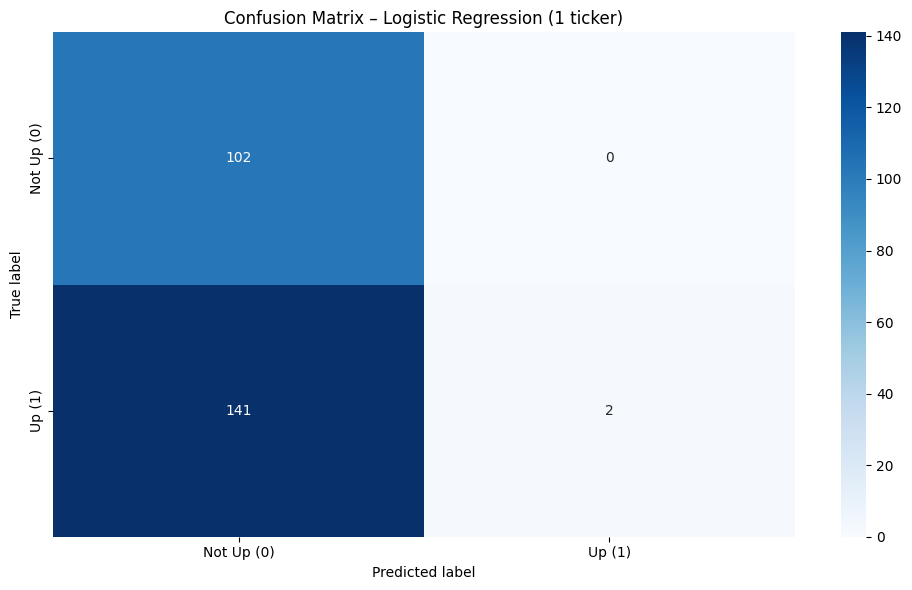

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
labels = ['Not Up (0)', 'Up (1)']

plt.figure(figsize=(10, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix – Logistic Regression (1 ticker)')
plt.tight_layout()
plt.show()


Point to the four numbers:

Top‑left (102): days when the stock did not go up and the model also said “not up” → these are correct “no” decisions.

Top‑right (0): days when it did not go up but the model said “up” → we have zero of these.

Bottom‑left (141): days when the stock did go up, but the model still said “not up” → these are the big problem, missed opportunities.

Bottom‑right (2): days when it did go up and the model said “up” → only 2 good “yes” calls.


In [35]:
y_test.value_counts(normalize=True)


target_up
1    0.583673
0    0.416327
Name: proportion, dtype: float64